<a href="https://colab.research.google.com/github/alaycheme25/chemeng277_batteryproject/blob/main/Regularization_CV_ErrorReports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
pip install periodictable


In [76]:
pip install paretoset

In [136]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import json
import pandas as pd
from sklearn.metrics import roc_curve, auc, r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable

In [137]:
# Importing the new_data file
pdata = pd.read_excel('mp_battery_data_new.csv.xlsx')

In [115]:
pdata.shape

(5786, 126)

In [138]:
# Trimming the data:
index = np.where("fields_not_requested_y" == np.array(pdata.columns.tolist()))[0][0]
pdata = pdata.iloc[:, 2:index]
pdata.drop(columns=["fields_not_requested_x", "host_structure", "structure", "material_id", "id_charge","id_discharge"], axis=1, inplace=True)
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,formation_energy_per_atom,band_gap
0,Li0-3Ce,Li,['Ce'],1,Ce,Li3Ce,2.951183,-0.444846,499.595769,-222.242937,0,0.333634,2.592432,0.333634,0
1,Li0-3Sb,Li,['Sb'],1,Sb,Li3Sb,1.569237,1.015953,563.913254,572.909146,0.328351,0,3.378028,-0.744135,0.7074
2,Li0-0.17C,Li,['C'],1,C,LiC6,0.025414,0.084405,339.236925,28.633212,0.011936,0.002406,2.237712,-0.034716,0
3,Li4.25-4.4Sn,Li,['Sn'],1,Li17Sn4,Li22Sn5,0.00945,-0.362516,26.93609,-9.764758,0,0.01007,2.583328,-0.330999,0
4,Li0-1Bi,Li,['Bi'],1,Bi,LiBi,0.368255,0.796796,124.126099,98.903144,0.049545,0,7.527518,-0.415156,0


In [139]:
# Getting the fittable data for given elements
fitdata = pdata.iloc[:, 6:]
rows_with_strings = []

# Check if there are any strings in the data
for i in range(1, len(fitdata.columns)):
    for j in range(len(fitdata)):
        if type(fitdata.iloc[j, i]) == str or fitdata.iloc[j, i] == "None" or fitdata.iloc[j, i] == "none" or np.isnan(fitdata.iloc[j, i]):
            rows_with_strings.append(j)
pdata = pdata.drop(rows_with_strings, inplace=False)
fitdata = fitdata.drop(rows_with_strings, inplace=False)

# In elements column, remove all [, ], and ' characters
pdata["elements"] = pdata["elements"].apply(lambda x: x.replace("[", "").replace("]", "").replace(" ", "").replace("'", ""))
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,formation_energy_per_atom,band_gap
0,Li0-3Ce,Li,Ce,1,Ce,Li3Ce,2.951183,-0.444846,499.595769,-222.242937,0,0.333634,2.592432,0.333634,0
1,Li0-3Sb,Li,Sb,1,Sb,Li3Sb,1.569237,1.015953,563.913254,572.909146,0.328351,0,3.378028,-0.744135,0.7074
2,Li0-0.17C,Li,C,1,C,LiC6,0.025414,0.084405,339.236925,28.633212,0.011936,0.002406,2.237712,-0.034716,0
3,Li4.25-4.4Sn,Li,Sn,1,Li17Sn4,Li22Sn5,0.00945,-0.362516,26.93609,-9.764758,0,0.01007,2.583328,-0.330999,0
4,Li0-1Bi,Li,Bi,1,Bi,LiBi,0.368255,0.796796,124.126099,98.903144,0.049545,0,7.527518,-0.415156,0


In [140]:
# Centering the data
for i in range(0, len(fitdata.columns)):
    fitdata.iloc[:, i] -=  np.nanmean(fitdata.iloc[:, i])
fitdata = fitdata.fillna(0)
fitdata = fitdata.astype(float)


/tmp/ipython-input-3130102122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fitdata = fitdata.fillna(0)


In [141]:
fitdata.head()

,max_delta_volume,average_voltage,capacity_grav,energy_grav,stability_charge,stability_discharge,density,formation_energy_per_atom,band_gap
0,2.601190,-3.075212,351.571799,-583.375288,-0.108948,0.207375,-1.441571,2.498688,-1.139843
1,1.219244,-1.614414,415.889284,211.776794,0.219403,-0.126259,-0.655975,1.420918,-0.432443
2,-0.324579,-2.545962,191.212956,-332.499139,-0.097012,-0.123853,-1.796291,2.130337,-1.139843
3,-0.340543,-2.992883,-121.087880,-370.897110,-0.108948,-0.116189,-1.450676,1.834055,-1.139843
4,0.018262,-1.833571,-23.897871,-262.229208,-0.059403,-0.126259,3.493515,1.749897,-1.139843


### Performing the PCA Algorithm

In [142]:
# Change n_components if you want to reduce the dimensionality of the data. The default is to keep all components. Feel free to change any parameters of PCA as you see fit!
n_components = len(fitdata.columns)
pca = PCA(n_components=n_components)
pca.fit(fitdata)

PCA(n_components=9)

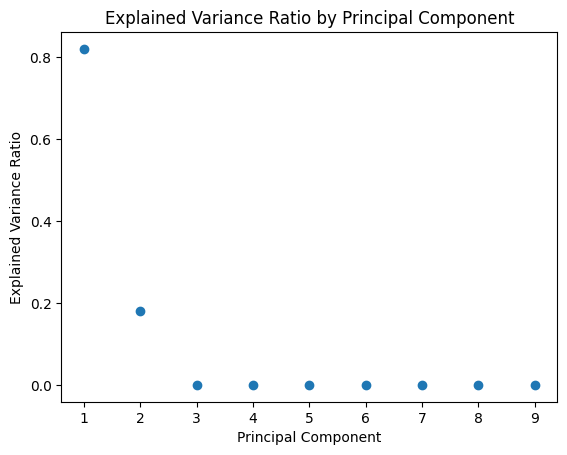

In [143]:
lambdas = pca.explained_variance_ratio_
plt.scatter(range(1, len(lambdas) + 1), lambdas)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.show()

#### Uncomment and run the following cell to project data onto chosen number of principal components:

In [122]:
#pca_data = pca.transform(fitdata)

#### Running ridge regression on the full dataset (fit data + element labels)
Ideally, datasets are broken up into different working electrolytes/element compounds, then modeled appropriately.
Then choose the most optimal combination given the molecule and see if it has any global maximuma for any tuning parameter.

In [145]:
scaler = MinMaxScaler() # introducing a normalizing factor for the data as opposed to centralising, for the paretoset.
# The model still uses centred data and hence has numerical stability
pdata_norm = pdata.iloc[:, 6:]
pdata_norm = fitdata.astype(float)
pdata_norm = pd.DataFrame(
    scaler.fit_transform(pdata_norm),
    columns=pdata_norm.columns,
    index=pdata_norm.index
)

In [124]:
pdata_norm.shape

(5778, 9)

In [146]:
front_index = paretoset.paretoset(pdata_norm, sense=["min", "max", "max", "min", "min", "min", "min", "min", "min"])
# Voltage and capacity alone are to be maximized - band gap, density and even voltage are vague measurements and depend on the application.
# A heavy duty battery for application like automobile battery is considered.
fitdata = fitdata.iloc[front_index]
pdata = pdata.iloc[front_index]

In [126]:
pdata.shape # Checking if pareto set removed significant share of data

(5584, 15)

In [127]:
fitdata.shape

(5584, 9)

In [128]:
# Get all elements in working_ion and elements columns from pdata
working_ion_mass = pdata["working_ion"].apply(lambda x: periodictable.elements.symbol(x).mass)
elements_mass = pdata["elements"].apply(lambda x: sum([periodictable.elements.symbol(el).mass for el in x.split(",")]))

####NEW MODEL: Capacity-based scoring

Gravimetric capacity is taken as the most important parameter for ranking a battery.

In [147]:
#battery_score = working_ion_mass + elements_mass*pdata["nelements"]
capacity = pdata["capacity_grav"]
battery_score = capacity

# Testing to see if the model works with a randomly generated sample of fitdata and battery score
fit_train, fit_test, score_train, score_test = train_test_split(fitdata, battery_score, test_size=0.1, random_state=42)

In [148]:
ridge = linear_model.Ridge(alpha=1.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(score_pred)

0.9999999999999999


In [149]:
best = np.where(battery_score == np.max(battery_score))[0][0]  #np.min(battery_score) was changed to max(battery_score) to obtain best capacity
print(pdata.iloc[best, 0:12])

battery_formula          Mg0-149Fe
working_ion                     Mg
elements                        Fe
nelements                        1
formula_charge                  Fe
formula_discharge          Mg149Fe
max_delta_volume        267.323478
average_voltage           0.008849
capacity_grav          2171.936774
energy_grav              19.219509
stability_charge          0.476699
stability_discharge              0
Name: 214, dtype: object


In [156]:
X = fitdata.drop(columns = ["capacity_grav"])
y = fitdata["capacity_grav"]

In [157]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=1.0))
])

In [158]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))

Mean R2: 0.3586921972193574
Mean MSE: 17403.782157418937
Mean MAE: 51.98857623540412
